In [ ]:
import os
path = os.getcwd()
print(path)
print(os.listdir())

import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", dataset_path)

/content
['.config', 'sample_data']
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [ ]:
# All Imports

# Fundamental classes
import numpy as np
import pandas as pd
import tensorflow as tf
import os

# Image processing
import cv2
from PIL import Image

# Plot
from sklearn import metrics
from sklearn.metrics import f1_score, accuracy_score,recall_score,confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization

# Time
import time
import datetime


from sklearn.metrics import accuracy_score
from keras.models import load_model
from sklearn.metrics import classification_report

print('completed')

completed


In [ ]:


# Load Dataset to this analysis
data = []
labels = []
classes = 43
cur_path = os.getcwd()

# Retrieving the images and their labels
for i in range(classes):
    path = os.path.join(dataset_path,'Train',str(i))
    images = os.listdir(path)
    print('loading class', i)
    for a in images:
        try:
            image = Image.open(path + '/'+ a)
            # print(image)
            image = image.resize((30,30))
            image = np.array(image)
            #sim = Image.fromarray(image)
            data.append(image)
            labels.append(i)
        except:
            print("Error loading image")
print('train data loaded')
print('size of train data:' ,len(data))
data = np.array(data)
labels = np.array(labels)

print(data.shape, labels.shape)

loading class 0
loading class 1
loading class 2
loading class 3
loading class 4
loading class 5
loading class 6
loading class 7
loading class 8
loading class 9
loading class 10
loading class 11
loading class 12
loading class 13
loading class 14
loading class 15
loading class 16
loading class 17
loading class 18
loading class 19
loading class 20
loading class 21
loading class 22
loading class 23
loading class 24
loading class 25
loading class 26
loading class 27
loading class 28
loading class 29
loading class 30
loading class 31
loading class 32
loading class 33
loading class 34
loading class 35
loading class 36
loading class 37
loading class 38
loading class 39
loading class 40
loading class 41
loading class 42
train data loaded
size of train data: 39209
(39209, 30, 30, 3) (39209,)


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

print('Train data has been splitted')
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Train data has been splitted
(31367, 30, 30, 3) (7842, 30, 30, 3) (31367,) (7842,)


In [ ]:
# Convert the labels into one hot encoding
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)
print('one hot encoding completed')
print(y_train.shape)

one hot encoding completed
(31367, 43)


In [ ]:
# Model construction
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(Conv2D(filters=64, kernel_size=(5,5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.15))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.20))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(rate=0.25))
model.add(Dense(43, activation='softmax'))

# # Initial Conv layers
# model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=X_train.shape[1:]))
# model.add(BatchNormalization())
# model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
# model.add(MaxPool2D(pool_size=(2, 2)))
# model.add(Dropout(rate=0.2))

# # Middle Conv layers
# model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
# model.add(BatchNormalization())
# model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
# model.add(MaxPool2D(pool_size=(2, 2)))
# model.add(Dropout(rate=0.25))

# # Final Conv layers
# model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
# model.add(BatchNormalization())
# model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
# model.add(MaxPool2D(pool_size=(2, 2)))
# model.add(Dropout(rate=0.3))

# # Fully connected layers
# model.add(Flatten())
# model.add(Dense(512, activation='relu'))
# model.add(Dropout(rate=0.4))
# model.add(Dense(43, activation='softmax'))

# Model compilation
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print('model created yet to train')

model.summary()

NameError: name 'Sequential' is not defined

In [ ]:
# Training
with tf.device('/GPU:0'):
    epochs = 10
    history1 = model.fit(X_train, y_train, batch_size=128, epochs=epochs, validation_data=(X_test, y_test))

Epoch 1/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 158s 634ms/step - accuracy: 0.4366 - loss: 3.0569 - val_accuracy: 0.9663 - val_loss: 0.1394
Epoch 2/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 201s 632ms/step - accuracy: 0.9477 - loss: 0.2003 - val_accuracy: 0.9842 - val_loss: 0.0827
Epoch 3/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 155s 630ms/step - accuracy: 0.9684 - loss: 0.1253 - val_accuracy: 0.9893 - val_loss: 0.0557
Epoch 4/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 155s 632ms/step - accuracy: 0.9775 - loss: 0.0893 - val_accuracy: 0.9878 - val_loss: 0.0614
Epoch 5/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 202s 633ms/step - accuracy: 0.9838 - loss: 0.0578 - val_accuracy: 0.9922 - val_loss: 0.0352
Epoch 6/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 156s 634ms/step - accuracy: 0.9851 - loss: 0.0608 - val_accuracy: 0.9844 - val_loss: 0.0728
Epoch 7/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 201s 631ms/step - accuracy: 0.9836 - loss: 0.0622 - val_accuracy: 0.9946 - val_loss: 0.0289
Epoch 8/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 202s 632ms/step - accuracy: 0.9844 -

In [ ]:
# Auxiliary Functions
def date_time(x):
    if x==1:
        return 'Timestamp: {:%Y-%m-%d %H:%M:%S}'.format(datetime.datetime.now())
    if x==2:
        return 'Timestamp: {:%Y-%b-%d %H:%M:%S}'.format(datetime.datetime.now())
    if x==3:
        return 'Date now: %s' % datetime.datetime.now()
    if x==4:
        return 'Date today: %s' % datetime.date.today()


def plot_performance(history=None, figure_directory=None, ylim_pad=[0, 0]):
    xlabel = 'Epoch'
    legends = ['Training', 'Validation']

    plt.figure(figsize=(20, 5))

    y1 = history.history['accuracy']
    y2 = history.history['val_accuracy']

    min_y = min(min(y1), min(y2))-ylim_pad[0]
    max_y = max(max(y1), max(y2))+ylim_pad[0]


    plt.subplot(121)

    plt.plot(y1)
    plt.plot(y2)

    plt.title('Model Accuracy\n'+date_time(1), fontsize=17)
    plt.xlabel(xlabel, fontsize=15)
    plt.ylabel('Accuracy', fontsize=15)
    plt.ylim(min_y, max_y)
    plt.legend(legends, loc='upper left')
    plt.grid()

    y1 = history.history['loss']
    y2 = history.history['val_loss']

    min_y = min(min(y1), min(y2))-ylim_pad[1]
    max_y = max(max(y1), max(y2))+ylim_pad[1]


    plt.subplot(122)

    plt.plot(y1)
    plt.plot(y2)

    plt.title('Model Loss\n'+date_time(1), fontsize=17)
    plt.xlabel(xlabel, fontsize=15)
    plt.ylabel('Loss', fontsize=15)
    plt.ylim(min_y, max_y)
    plt.legend(legends, loc='upper left')
    plt.grid()
    if figure_directory:
        plt.savefig(figure_directory+"/history")

    plt.show()

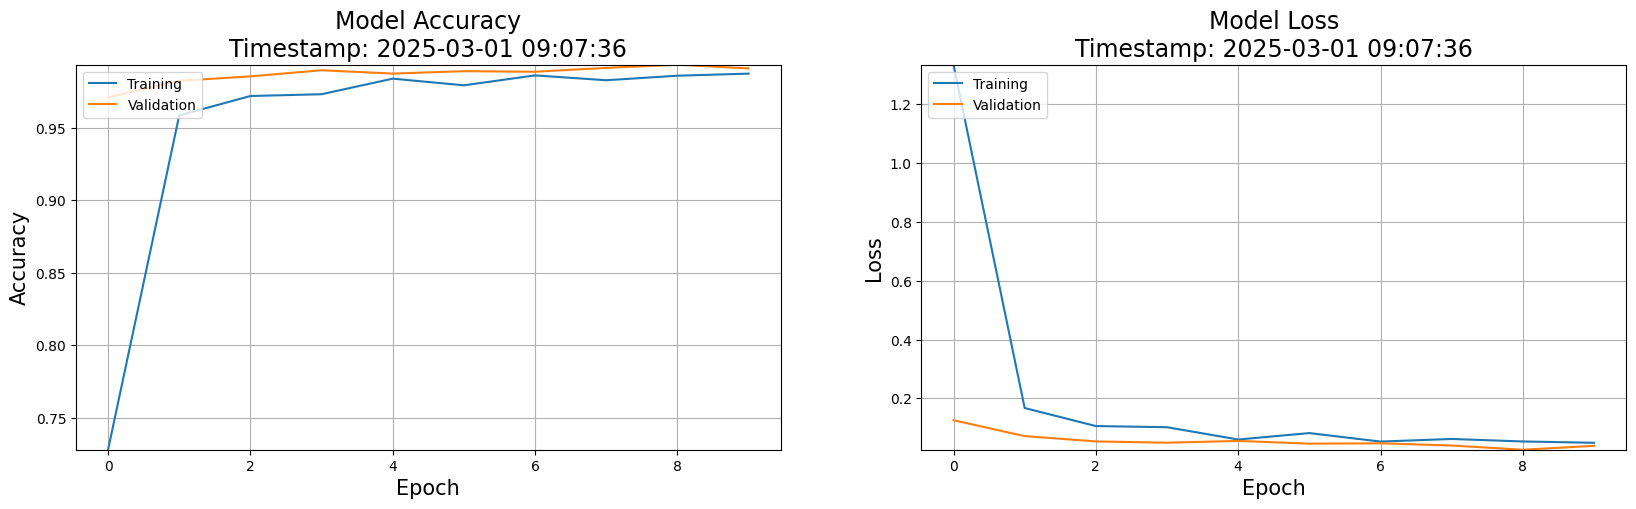

In [ ]:
# Performance visualization
plot_performance(history=history1)

In [ ]:
# Testing accuracy on test dataset
# Load test labels
y_test = pd.read_csv(dataset_path+'/' + 'Test.csv')
labels = y_test["ClassId"].values
imgs = y_test["Path"].values

# Populate the test data array
data=[]
with tf.device('/GPU:0'):
    for img in imgs:
        image = Image.open(dataset_path + '/'+ img)
        image = image.resize([30, 30])
        data.append(np.array(image))

X_test=np.array(data)

In [ ]:
with tf.device('/GPU:0'):
    pred = np.argmax(model.predict(X_test), axis=-1)

# Print accuracy
print("accuracy: ")
print(accuracy_score(labels, pred))
print("f1 score: ")
print(f1_score(labels, pred, average='weighted'))
print("recall: ")
print(recall_score(labels, pred, average='weighted'))

395/395 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step
accuracy: 
0.9648456057007125
f1 score: 
0.9639804125653513
recall: 
0.9648456057007125


In [ ]:
print("classification_report: ")
print(classification_report(labels, pred))

classification_report: 
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        60
           1       0.93      0.98      0.95       720
           2       0.97      0.99      0.98       750
           3       0.97      0.98      0.97       450
           4       0.99      0.98      0.98       660
           5       0.93      0.98      0.95       630
           6       1.00      0.85      0.92       150
           7       1.00      0.91      0.95       450
           8       0.95      0.93      0.94       450
           9       0.91      1.00      0.95       480
          10       0.99      0.99      0.99       660
          11       0.97      0.99      0.98       420
          12       0.99      0.98      0.99       690
          13       1.00      0.99      1.00       720
          14       1.00      0.99      0.99       270
          15       0.98      0.99      0.98       210
          16       0.99      0.99      0.99       150
   

In [ ]:
#Save the model for future usage
model.save('traffic_sign_classifier.h5')
print('model saved')

model saved


Monitoring input folder for images...
upload the image in input folder.......
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step


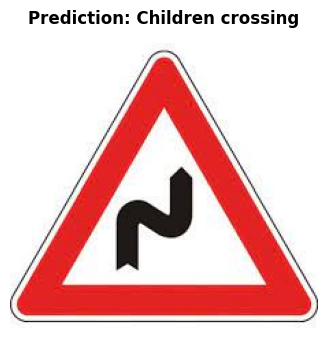

Processed and deleted: input/images.jpeg
uplaod the next image......
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


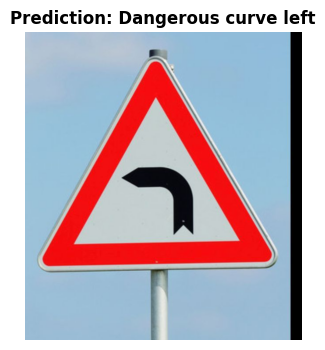

Processed and deleted: input/WhatsApp Image 2025-03-01 at 15.26.44.jpeg
uplaod the next image......
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


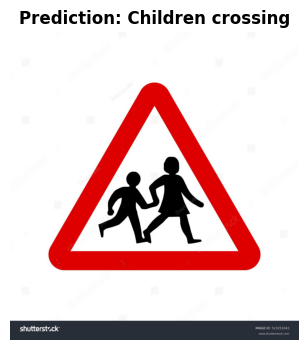

Processed and deleted: input/stock-vector-school-sign-uk-children-sign-school-crossing-523251043.jpg
uplaod the next image......
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


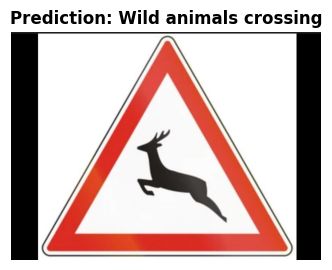

Processed and deleted: input/WhatsApp Image 2025-03-01 at 15.09.17.jpeg
uplaod the next image......
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


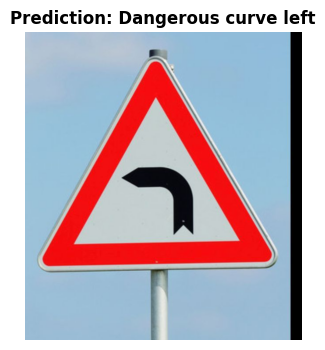

Processed and deleted: input/WhatsApp Image 2025-03-01 at 15.26.44.jpeg
uplaod the next image......


In [ ]:
import os
import time
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Load the trained model
model = tf.keras.models.load_model("traffic_sign_classifier.h5")

# Dictionary mapping class labels
# Dictionary to label all traffic signs
classes = { 1:'Speed limit (20km/h)',
           2:'Speed limit (30km/h)',
           3:'Speed limit (50km/h)',
           4:'Speed limit (60km/h)',
           5:'Speed limit (70km/h)',
           6:'Speed limit (80km/h)',
           7:'End of speed limit (80km/h)',
           8:'Speed limit (100km/h)',
           9:'Speed limit (120km/h)',
           10:'No passing',
           11:'No passing veh over 3.5 tons',
           12:'Right-of-way at intersection',
           13:'Priority road',
           14:'Yield',
           15:'Stop',
           16:'No vehicles',
           17:'Veh > 3.5 tons prohibited',
           18:'No entry',
           19:'General caution',
           20:'Dangerous curve left',    ##### IMP
           21:'Dangerous curve right',
           22:'Double curve',
           23:'Bumpy road',
           24:'Slippery road',
           25:'Road narrows on the right',
           26:'Road work',                   ##### IMP
           27:'Traffic signals',
           28:'Pedestrians',
           29:'Children crossing',          ##### IMP
           30:'Bicycles crossing',
           31:'Beware of ice/snow',
           32:'Wild animals crossing',      ##### IMP
           33:'End speed + passing limits',
           34:'Turn right ahead',
           35:'Turn left ahead',
           36:'Ahead only',
           37:'Go straight or right',
           38:'Go straight or left',
           39:'Keep right',
           40:'Keep left',
           41:'Roundabout mandatory',
           42:'End of no passing',
           43:'End no passing vehicle with a weight greater than 3.5 tons'

           }

# Paths
INPUT_FOLDER = "input"
os.makedirs(INPUT_FOLDER, exist_ok=True)


def classify_image(img_path):
    """Classifies an image and returns the predicted class label."""
    image = Image.open(img_path)
    image = image.resize((30, 30))  # Resize to match model input
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    image = np.array(image)  # Convert to numpy array

    prediction = model.predict(image)
    class_idx = np.argmax(prediction) + 1  # Adjust index for class dictionary
    return classes.get(class_idx, "Unknown"), img_path


def display_result(image_path, prediction):
    """Displays the image and its classification."""
    image = Image.open(image_path)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {prediction}", fontsize=12, fontweight="bold")
    plt.show()


def process_images():
    """Monitors the input folder for new images, classifies them, and deletes after processing."""
    print('upload the image in input folder.......')
    while True:
        images = [f for f in os.listdir(INPUT_FOLDER) if f.lower().endswith(("png", "jpg", "jpeg"))]

        if images:
            img_path = os.path.join(INPUT_FOLDER, images[0])
            prediction, img_path = classify_image(img_path)
            display_result(img_path, prediction)

            os.remove(img_path)  # Remove image after classification
            print(f"Processed and deleted: {img_path}")
            print('uplaod the next image......')

        time.sleep(2)  # Check every 2 seconds




if __name__ == "__main__":
    print("Monitoring input folder for images...")
    process_images()
